## Ch5. The forecaster's toolbox Forecasting: Principles & Practice (Python Edition) Extracted from: fpppy-05-toolbox.qmd

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## [Slide 1] Chapter Overview

In [2]:
from statsforecast import StatsForecast
from statsforecast.models import (
    HistoricAverage, Naive,
    RandomWalkWithDrift, SeasonalNaive, SklearnModel,
)
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape, mase

## [Slide 3] 5.1 The Six-Step Workflow

In [3]:
gdp_df = (
    pd.read_csv("data/global_economy.csv",
                parse_dates=["ds"])
    [["unique_id","ds","GDP","Population"]]
    .assign(
        GDP=lambda x: x["GDP"].interpolate(),
        Population=lambda x: x["Population"].interpolate(),
        y=lambda x: x["GDP"] / x["Population"],
    )
)

## [Slide 5] 5.1 Specify and Estimate

In [4]:
from utilsforecast.feature_engineering import pipeline, trend
from fpppy.models import LinearRegression

sweden_df = (
    gdp_df
    .loc[lambda x: x["unique_id"] == "Sweden"]
    [["unique_id","ds","y"]]
)

Create trend feature

In [5]:
train_features, valid_features = pipeline(
    sweden_df, features=[trend], freq="Y", h=3
)

Fit linear trend model

In [6]:
trend_model = SklearnModel(LinearRegression())
sf = StatsForecast(models=[trend_model], freq="Y")
sf.fit(df=train_features)

fcasts = sf.predict(h=3, X_df=valid_features)
model = sf.fitted_[0][0].model_["model"]
fcasts = model.add_prediction_intervals(
    fcasts, valid_features.rename(
        columns={"trend": "x1"}))

## [Slide 8] 5.2 Benchmark Methods in Python

In [7]:
production_df = pd.read_csv(
    "data/aus_production_formatted.csv",
    parse_dates=["ds"]
)
train = production_df.loc[
    lambda x: (x["unique_id"]=="Beer") &
              (x["ds"] < "2007")
]
test = production_df.loc[
    lambda x: (x["unique_id"]=="Beer") &
              (x["ds"] >= "2007")
]

sf = StatsForecast(
    models=[
        HistoricAverage(),    # Mean
        Naive(),              # Naive
        SeasonalNaive(4),     # Seasonal Naive (q=4)
        RandomWalkWithDrift() # Drift
    ],
    freq=pd.offsets.QuarterBegin(1)
)
sf.fit(train)
fcasts = sf.predict(h=14).assign(y=test["y"].to_numpy())

## [Slide 11] 5.3 Fitted Values and Residuals

In [8]:
sf = StatsForecast(
    models=[HistoricAverage()], freq="Q"
)
sf.forecast(h=14, df=train, fitted=True)
fitted_values = sf.forecast_fitted_values()

df = train.assign(
    fitted=fitted_values["HistoricAverage"].to_numpy(),
    resid=lambda x: x["y"] - x["fitted"],
)

## [Slide 15] 5.4 Diagnostic Plots in Python

In [9]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

Naive residuals for Google stock

In [10]:
resid = train.assign(resid=lambda x: x["y"].diff())

Three-panel diagnostic

(array([ 3.,  3.,  6.,  9., 20., 26., 22.,  9., 10., 21., 15.,  9.,  2.,
         7., 10., 15.,  9.,  4.,  1.,  2.]),
 array([-135.  , -119.75, -104.5 ,  -89.25,  -74.  ,  -58.75,  -43.5 ,
         -28.25,  -13.  ,    2.25,   17.5 ,   32.75,   48.  ,   63.25,
          78.5 ,   93.75,  109.  ,  124.25,  139.5 ,  154.75,  170.  ]),
 <BarContainer object of 20 artists>)

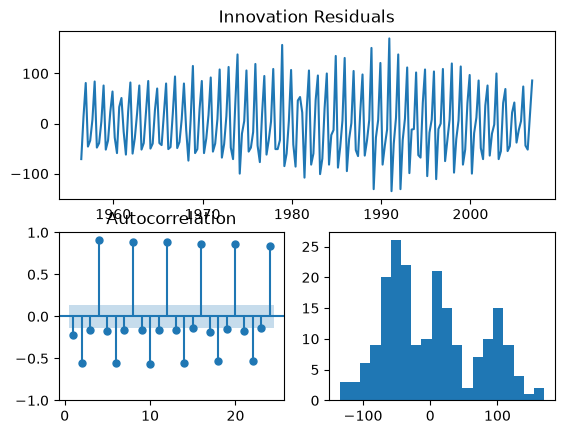

In [11]:
fig, axes = plt.subplot_mosaic(
    [["resid","resid"],["acf","hist"]]
)
axes["resid"].plot(train["ds"], resid["resid"])
axes["resid"].set(title="Innovation Residuals")
plot_acf(resid["resid"].dropna(), zero=False,
         bartlett_confint=False, ax=axes["acf"])
axes["hist"].hist(resid["resid"].dropna(), bins=20)

Ljung-Box test

In [12]:
lb_test = acorr_ljungbox(
    resid["resid"].dropna(), boxpierce=True
)

## [Slide 18] 5.5 Prediction Interval Formulas for Benchmark Methods

In [13]:
naive_method = Naive()
sf = StatsForecast(models=[naive_method], freq="Q")
fcasts = sf.forecast(df=train, h=10, level=[80, 95])

## [Slide 20] 5.5 Bootstrap Prediction Intervals

In [14]:
sf = StatsForecast(models=[Naive()], freq="Q")
sf.forecast(h=30, df=train, fitted=True)
fitted = sf.forecast_fitted_values()
errors = (fitted["y"] - fitted["Naive"]).iloc[1:].to_numpy()
errors -= errors.mean()  # Centre residuals
last_obs = train["y"].iloc[-1]

def generate_sim_df(num_sims, h):
    steps = np.random.choice(errors, size=(num_sims, h))
    sims = last_obs + steps.cumsum(axis=1)
    return pd.DataFrame(
        sims.T,
        columns=[f"sim_{i}" for i in range(num_sims)]
    )

Bootstrap quantiles from 5000 simulations

In [15]:
raw_df = generate_sim_df(num_sims=5000, h=30)
lo95 = raw_df.quantile(0.025, axis="columns")
hi95 = raw_df.quantile(0.975, axis="columns")

## [Slide 24] 5.6 Bias Adjustment for Back-Transformed Forecasts

In [16]:
fcasts = fcasts_log.assign(
    RWD_adjusted=np.exp(fcasts_log["RWD"]) *
                 (1 + sigma_h**2 / 2)
)

NameError: name 'fcasts_log' is not defined

## [Slide 26] 5.7 Decomposition-Based Forecasting

In [17]:
us_retail_employment_df = (
    pd.read_csv("data/us_employment.csv", parse_dates=["ds"])
    .loc[lambda x: (x["unique_id"] == "Retail Trade") & (x["ds"] >= "1990-01-01")]
    .reset_index(drop=True)
)


In [18]:
from statsmodels.tsa.seasonal import STL


In [19]:
stl = STL(us_retail_employment_df["y"].to_numpy(),
           period=12, robust=True)
res = stl.fit()
train_df = us_retail_employment_df.assign(
    seasonal=res.seasonal,
    y_adjusted=lambda x: x["y"] - x["seasonal"],
)

## [Slide 28] 5.7 Decomposition Forecasting: Full Example Forecast the seasonally adjusted component

In [20]:
sf_naive = StatsForecast(models=[Naive()], freq="M")
adj_fcasts = sf_naive.forecast(
    h=24, level=[80,95],
    df=train_df, target_col="y_adjusted"
)

Forecast the seasonal component

In [21]:
sf_seasonal = StatsForecast(
    models=[SeasonalNaive(12, alias="Seasonal")], freq="M"
)
seas_fcasts = sf_seasonal.forecast(
    h=24, level=[80,95],
    df=train_df, target_col="seasonal"
)

Combine

In [22]:
fcasts = adj_fcasts.merge(
    seas_fcasts, on=["unique_id","ds"]
).assign(
    combined=lambda x: x["Naive"] + x["Seasonal"]
)

## [Slide 31] 5.8 Accuracy Evaluation in Python

In [23]:
beers_df = production_df.loc[lambda x: x["unique_id"] == "Beer"]


In [24]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mase
from functools import partial

train_df = beers_df.loc[
    lambda x: x["ds"].dt.year <= 2007
]
test_df = beers_df.loc[
    lambda x: x["ds"].dt.year > 2007
]

sf = StatsForecast(
    freq="Q",
    models=[HistoricAverage(), Naive(),
            SeasonalNaive(4), RandomWalkWithDrift()]
)
preds = (
    sf.forecast(df=train_df, h=10)
    .assign(y=test_df["y"].to_numpy())
)
evaluation = evaluate(
    preds, train_df=train_df,
    metrics=[rmse, mae, partial(mase, seasonality=4)]
)

## [Slide 35] 5.9 CRPS in Python

In [25]:
from utilsforecast.losses import mqloss

levels = list(np.arange(0.1, 100, 1/10))
preds = sf.forecast(df=train_df, h=len(test_df),
                     level=levels)

models = ["RWD", "HistoricAverage", "Naive"]
raw_crps = evaluate(df=preds, models=models,
                     metrics=[mqloss], level=levels)

ColumnNotFoundError: The following columns were not found: ['y']

Hint: Did you mean one of these columns: ['unique_id', 'ds', 'HistoricAverage', 'HistoricAverage-lo-0.1', 'HistoricAverage-lo-0.2', 'HistoricAverage-lo-0.30000000000000004', 'HistoricAverage-lo-0.4', 'HistoricAverage-lo-0.5', 'HistoricAverage-lo-0.6', 'HistoricAverage-lo-0.7000000000000001', 'HistoricAverage-lo-0.8', 'HistoricAverage-lo-0.9', 'HistoricAverage-lo-1.0', 'HistoricAverage-lo-1.1', 'HistoricAverage-lo-1.2000000000000002', 'HistoricAverage-lo-1.3000000000000003', 'HistoricAverage-lo-1.4000000000000001', 'HistoricAverage-lo-1.5000000000000002', 'HistoricAverage-lo-1.6', 'HistoricAverage-lo-1.7000000000000002', 'HistoricAverage-lo-1.8000000000000003', 'HistoricAverage-lo-1.9000000000000001', 'HistoricAverage-lo-2.0', 'HistoricAverage-lo-2.1', 'HistoricAverage-lo-2.2', 'HistoricAverage-lo-2.3000000000000003', 'HistoricAverage-lo-2.4000000000000004', 'HistoricAverage-lo-2.5000000000000004', 'HistoricAverage-lo-2.6

CRPS = 2 * mean quantile loss

In [26]:
crps_series = 2 * raw_crps[models].iloc[0]

NameError: name 'raw_crps' is not defined

Skill score relative to Naive

In [27]:
naive_crps = crps_series.loc["Naive"]
skill = (naive_crps - crps_series) / naive_crps

NameError: name 'crps_series' is not defined

## [Slide 38] 5.10 Cross-Validation in Python

In [28]:
goog_df = (
    pd.read_csv("data/gafa_stock.csv", parse_dates=["ds"])
    .loc[lambda x: x["unique_id"] == "GOOG_Close"]
    .reset_index(drop=True)
)


In [29]:
goog_2015 = goog_df.loc[
    lambda x: x["ds"].dt.year == 2015
].copy()

drift_method = RandomWalkWithDrift()
sf = StatsForecast(models=[drift_method], freq="B")
cv_df = sf.cross_validation(
    h=1, df=goog_2015,
    step_size=1, test_size=249
)

Evaluate across all validation windows

In [30]:
cv_eval = evaluate(cv_df, metrics=[rmse],
                    models=["RWD"])

## [Slide 40] 5.10 Cross-Validation Across Forecast Horizons

[Text(0.5, 1.0, 'RMSE vs. Forecast Horizon'),
 Text(0.5, 0, 'h'),
 Text(0, 0.5, 'RMSE')]

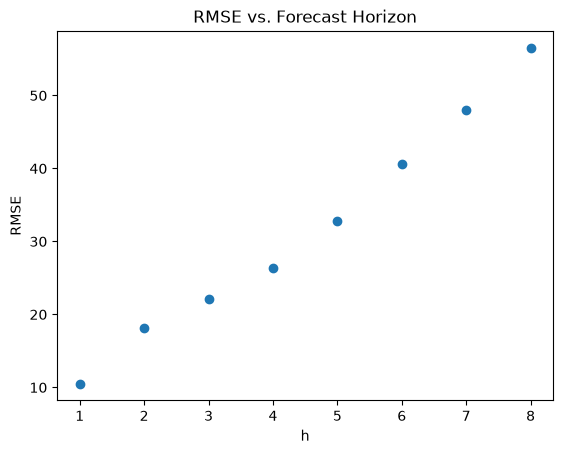

In [31]:
rmses = []
horizons = np.arange(1, 9)
for h in horizons:
    sf = StatsForecast(
        models=[RandomWalkWithDrift()], freq="B"
    )
    cv_df = sf.cross_validation(
        h=h, df=goog_2015,
        step_size=1, test_size=249
    )
    cv_eval = evaluate(cv_df, metrics=[rmse],
                        models=["RWD"])
    rmses.append(cv_eval["RWD"].iloc[0])

fig, ax = plt.subplots()
ax.scatter(horizons, rmses)
ax.set(title="RMSE vs. Forecast Horizon",
       xlabel="h", ylabel="RMSE")